<a href="https://colab.research.google.com/github/ezraaufaaa/m-pajak-sentiment-analysis/blob/main/indobert_vs_mbert_mpajak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analisis Sentimen Ulasan Pengguna Menggunakan Perbandingan Model IndoBERT dan mBERT**

Perkembangan teknologi digital menyebabkan semakin banyak pengguna internet memberikan ulasan dan opini pada berbagai platform media sosial maupun aplikasi digital. Ulasan tersebut dapat dimanfaatkan untuk mengetahui sentimen masyarakat terhadap suatu layanan, produk, maupun aplikasi.

Analisis sentimen merupakan salah satu cabang dari Natural Language Processing (NLP) yang digunakan untuk mengidentifikasi opini pengguna ke dalam kategori positif, negatif, maupun netral. Dalam penelitian ini digunakan dua model berbasis transformer yaitu IndoBERT dan mBERT untuk melakukan klasifikasi sentimen pada data ulasan pengguna.

IndoBERT merupakan model pre-trained khusus bahasa Indonesia sehingga memiliki pemahaman konteks bahasa Indonesia yang lebih baik. Sedangkan mBERT (Multilingual BERT) merupakan model multilingual yang mampu memahami banyak bahasa sekaligus, termasuk bahasa Indonesia.

Penelitian ini bertujuan untuk membandingkan performa kedua model dalam melakukan klasifikasi sentimen sehingga dapat diketahui model mana yang memiliki performa lebih baik pada dataset berbahasa Indonesia.

Berikut tahapan penelitian yang dilakukan:

1. Pengumpulan dataset
2. Preprocessing data
3. Pelabelan sentimen
4. Tokenisasi menggunakan tokenizer BERT
5. Training model IndoBERT
6. Training model mBERT
7. Evaluasi model
8. Perbandingan hasil performa
9. Analisis hasil penelitian

**Tools dan Library yang Digunakan**

Penelitian ini menggunakan beberapa tools dan library berikut:

1. Python
2. Google Colab
3. Pandas
4. NumPy
5. Scikit-learn
6. TensorFlow / PyTorch
7. HuggingFace Transformers
8. Matplotlib
9. Seaborn

**Instalasi Library yang Digunakan**
Perintah `pip install google-play-scraper pandas` digunakan untuk menginstal library Python yang dibutuhkan dalam proses pengambilan dan pengolahan data pada penelitian analisis sentimen. Library `google-play-scraper` digunakan untuk melakukan scraping atau pengambilan data ulasan aplikasi secara otomatis dari Google Play Store, sehingga peneliti dapat memperoleh dataset berupa komentar dan rating pengguna aplikasi yang nantinya akan digunakan sebagai data penelitian. Sedangkan library `pandas` digunakan untuk mengelola dan memproses data dalam bentuk tabel atau dataframe, seperti membaca data, membersihkan data, menampilkan dataset, melakukan manipulasi kolom, serta mempermudah proses preprocessing sebelum data digunakan dalam pelatihan model IndoBERT dan mBERT. Perintah `pip install` sendiri berfungsi untuk mengunduh dan memasang library tersebut ke dalam environment Python di Google Colab agar dapat digunakan pada proses penelitian.

In [ ]:
pip install google-play-scraper pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


## Import Library dan Proses Scraping Dataset

Kode program berikut digunakan untuk melakukan proses pengambilan dataset ulasan pengguna aplikasi dari Google Play Store yang nantinya akan digunakan dalam penelitian analisis sentimen. Pada tahap awal dilakukan import beberapa library Python seperti `google_play_scraper`, `pandas`, `matplotlib`, `os`, dan `datetime`. Library `google_play_scraper` digunakan untuk mengambil data ulasan aplikasi secara otomatis dari Google Play Store, `pandas` digunakan untuk mengelola data dalam bentuk dataframe, `matplotlib` digunakan untuk visualisasi data dalam bentuk grafik, `os` digunakan untuk membuat folder penyimpanan dataset secara otomatis, dan `datetime` digunakan untuk memberikan timestamp pada nama file agar setiap dataset yang disimpan memiliki nama yang unik.

Pada proses scraping data, digunakan `app_id = 'id.go.pajak.djp'` yang menunjukkan bahwa data diambil dari aplikasi DJP Pajak milik Direktorat Jenderal Pajak di Google Play Store. Parameter `lang='id'` digunakan agar ulasan yang diambil berbahasa Indonesia, sedangkan `country='id'` menunjukkan wilayah Indonesia. Parameter `sort=Sort.NEWEST` digunakan untuk mengambil ulasan terbaru dari pengguna, dan `count=12900` digunakan untuk menentukan jumlah maksimum ulasan yang diambil sebanyak 12.900 data.

Setelah proses scraping selesai, dilakukan pengecekan apakah data berhasil diperoleh atau tidak. Jika data kosong maka program akan menghentikan proses dan menampilkan pesan error. Selanjutnya data hasil scraping diubah menjadi dataframe menggunakan `pandas.DataFrame()` agar lebih mudah diproses pada tahap berikutnya. Dari seluruh data yang diperoleh, hanya kolom `content` dan `score` yang digunakan karena kedua kolom tersebut berisi isi ulasan pengguna dan rating aplikasi. Nama kolom kemudian diubah menjadi `text` dan `rating` agar lebih sederhana dan mudah dipahami.

Tahap berikutnya adalah proses pelabelan sentimen menggunakan fungsi `label_sentiment()`. Pada penelitian ini, rating 4 dan 5 dikategorikan sebagai sentimen positif (Positive), rating 3 sebagai sentimen netral (Neutral), sedangkan rating 1 dan 2 dikategorikan sebagai sentimen negatif (Negative). Pelabelan ini dilakukan secara otomatis menggunakan fungsi `apply()` pada dataframe sehingga setiap data ulasan memiliki label sentimen masing-masing.

Dataset yang telah selesai diproses kemudian disimpan secara otomatis ke dalam file CSV menggunakan format pemisah titik koma (`sep=';'`) dengan encoding UTF-8 agar kompatibel saat dibuka di berbagai aplikasi seperti Microsoft Excel. File disimpan ke dalam folder `dataset` dengan nama file berdasarkan waktu pembuatan menggunakan timestamp sehingga tidak terjadi penimpaan file secara otomatis.

Selanjutnya dilakukan perhitungan distribusi sentimen menggunakan `value_counts()` untuk mengetahui jumlah data positif, negatif, dan netral dalam dataset. Hasil distribusi tersebut kemudian divisualisasikan dalam bentuk grafik batang menggunakan `matplotlib` agar penyebaran data sentimen lebih mudah dianalisis. Pada tahap akhir, file CSV secara otomatis diunduh menggunakan `files.download()` sehingga dataset dapat langsung disimpan oleh pengguna dari Google Colab ke perangkat lokal untuk digunakan pada tahap preprocessing dan pelatihan model IndoBERT maupun mBERT selanjutnya.


🔍 Mengambil data dari Play Store...
✅ Jumlah data: 7124

💾 CSV otomatis tersimpan di: dataset/dataset_playstore_20260428_184853.csv

📊 Distribusi Sentimen:
sentiment
Negative    5624
Positive    1316
Neutral      184
Name: count, dtype: int64


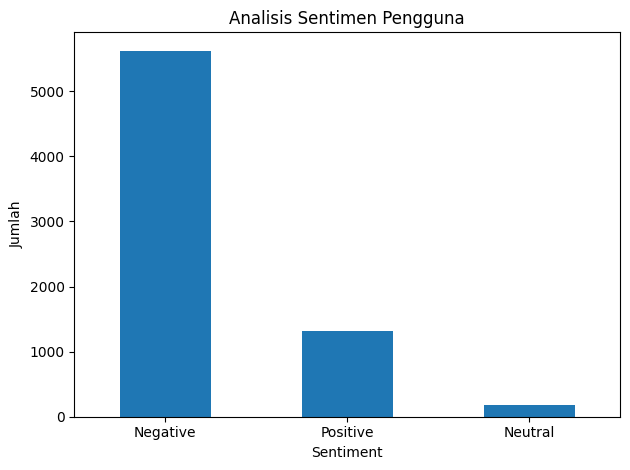

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime

# =========================
# 1. SCRAPING DATA
# =========================
app_id = 'id.go.pajak.djp'

print("🔍 Mengambil data dari Play Store...")

result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=12900
)

# =========================
# 2. CEK DATA
# =========================
if len(result) == 0:
    print("❌ Data kosong! Ganti app_id atau cek koneksi.")
    exit()

df = pd.DataFrame(result)

# =========================
# 3. AMBIL KOLOM
# =========================
df = df[['content', 'score']]
df.columns = ['text', 'rating']

print("✅ Jumlah data:", len(df))

# =========================
# 4. LABEL SENTIMENT
# =========================
def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(label_sentiment)

# =========================
# 5. AUTO SAVE CSV (SMART)
# =========================
folder_name = "dataset"
os.makedirs(folder_name, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"{folder_name}/dataset_playstore_{timestamp}.csv"

# 🔥 FIX: pakai separator ;
df.to_csv(file_name, index=False, sep=';', encoding='utf-8-sig')

print(f"\n💾 CSV otomatis tersimpan di: {file_name}")

# =========================
# 6. HITUNG DISTRIBUSI
# =========================
sentiment_counts = df['sentiment'].value_counts()

print("\n📊 Distribusi Sentimen:")
print(sentiment_counts)

# =========================
# 7. VISUALISASI
# =========================
plt.figure()
sentiment_counts.plot(kind='bar')

plt.title("Analisis Sentimen Pengguna")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# =========================
# 8. DOWNLOAD CSV (COLAB)
# =========================
from google.colab import files
files.download(file_name)

## Visualisasi Distribusi Sentimen Menggunakan Diagram Pie

Kode program berikut digunakan untuk menampilkan visualisasi distribusi data sentimen pengguna dalam bentuk diagram pie (pie chart). Visualisasi ini bertujuan untuk mempermudah proses analisis terhadap proporsi jumlah data sentimen positif, netral, dan negatif yang diperoleh dari hasil scraping ulasan pengguna aplikasi. Pada awal kode, `plt.figure()` digunakan untuk membuat area atau kanvas grafik baru sebelum proses visualisasi dilakukan.

Selanjutnya, `sentiment_counts.plot(kind='pie', autopct='%1.1f%%')` digunakan untuk membuat diagram pie berdasarkan jumlah masing-masing kategori sentimen yang telah dihitung sebelumnya menggunakan `value_counts()`. Parameter `kind='pie'` menunjukkan bahwa grafik yang digunakan adalah diagram lingkaran, sedangkan `autopct='%1.1f%%'` digunakan untuk menampilkan persentase setiap kategori sentimen secara otomatis dengan format satu angka di belakang koma.

Bagian `plt.title("Distribusi Sentimen Pengguna")` digunakan untuk memberikan judul pada grafik agar memudahkan pengguna dalam memahami isi visualisasi. Kemudian `plt.ylabel('')` digunakan untuk menghilangkan label sumbu Y yang secara default muncul pada diagram pie sehingga tampilan grafik menjadi lebih rapi dan mudah dibaca. Terakhir, `plt.show()` digunakan untuk menampilkan hasil visualisasi diagram pie ke layar output Google Colab. Dengan visualisasi ini, peneliti dapat melihat secara langsung perbandingan proporsi sentimen positif, netral, dan negatif pada dataset yang digunakan dalam penelitian analisis sentimen.


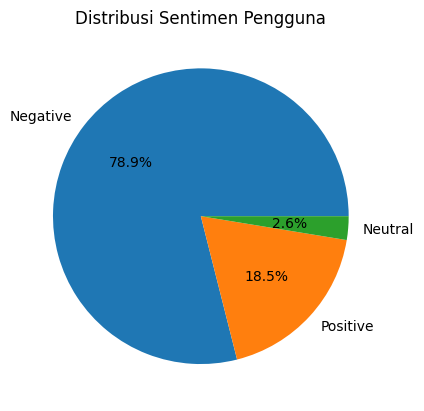

In [ ]:
plt.figure()

sentiment_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Distribusi Sentimen Pengguna")

plt.ylabel('')

plt.show()

## Instalasi Library untuk Pemodelan dan Evaluasi

Perintah `pip install transformers torch pandas matplotlib scikit-learn` digunakan untuk menginstal beberapa library utama yang dibutuhkan dalam proses pelatihan model, pengolahan data, visualisasi, dan evaluasi pada penelitian analisis sentimen menggunakan IndoBERT dan mBERT. Library `transformers` dari HuggingFace digunakan untuk mengakses model transformer seperti IndoBERT dan mBERT beserta tokenizer yang diperlukan dalam proses tokenisasi teks dan pelatihan model Natural Language Processing (NLP). Library `torch` atau PyTorch digunakan sebagai framework Deep Learning untuk menjalankan proses training, validasi, dan prediksi model berbasis neural network.

Selain itu, library `pandas` digunakan untuk mengelola dataset dalam bentuk dataframe sehingga mempermudah proses pembacaan, manipulasi, dan preprocessing data. Library `matplotlib` digunakan untuk membuat visualisasi data seperti grafik distribusi sentimen, confusion matrix, dan grafik evaluasi model agar hasil penelitian lebih mudah dianalisis. Sedangkan library `scikit-learn` digunakan untuk membantu proses machine learning dan evaluasi model seperti pembagian data training dan testing, perhitungan accuracy, precision, recall, F1-score, classification report, serta confusion matrix. Perintah `pip install` sendiri berfungsi untuk mengunduh dan memasang seluruh library tersebut ke dalam environment Python pada Google Colab agar seluruh proses penelitian dapat berjalan dengan baik.


In [ ]:
pip install transformers torch pandas matplotlib scikit-learn

## Implementasi Analisis Sentimen Menggunakan IndoBERT dan Hybrid Classification

Kode program berikut digunakan untuk melakukan proses analisis sentimen terhadap ulasan pengguna aplikasi DJP Pajak yang diperoleh dari Google Play Store menggunakan pendekatan Artificial Intelligence berbasis transformer. Pada tahap awal dilakukan import beberapa library Python seperti `google_play_scraper`, `pandas`, `matplotlib`, `torch`, `transformers`, `sklearn`, `re`, dan `tqdm`. Library `google_play_scraper` digunakan untuk mengambil data ulasan aplikasi dari Google Play Store, `pandas` digunakan untuk pengolahan data dalam bentuk dataframe, `matplotlib` digunakan untuk visualisasi data, `torch` digunakan sebagai framework Deep Learning berbasis PyTorch, sedangkan `transformers` digunakan untuk memuat model IndoBERT yang digunakan dalam klasifikasi sentimen. Selain itu, `classification_report` dari `scikit-learn` digunakan untuk evaluasi performa model, `re` digunakan untuk preprocessing teks menggunakan regular expression, dan `tqdm` digunakan untuk menampilkan progress bar saat proses prediksi berlangsung.

Pada tahap scraping data, program mengambil ulasan dari aplikasi DJP Pajak dengan `app_id = 'id.go.pajak.djp'`. Data diambil menggunakan parameter bahasa Indonesia (`lang='id'`), wilayah Indonesia (`country='id'`), urutan ulasan terbaru (`sort=Sort.NEWEST`), dan jumlah data maksimal sebanyak 12.900 ulasan (`count=12900`). Setelah data berhasil diperoleh, program melakukan pengecekan apakah data kosong atau tidak. Jika proses scraping gagal atau tidak menghasilkan data, maka program akan menggunakan dataset dummy sebagai data cadangan agar proses penelitian tetap dapat berjalan.

Tahap berikutnya adalah preprocessing data menggunakan fungsi `clean_text()`. Pada proses ini dilakukan pembersihan teks dengan mengubah seluruh huruf menjadi lowercase, menghapus URL, menghapus simbol atau karakter khusus, serta menghapus spasi berlebih menggunakan regular expression. Tujuan preprocessing ini adalah agar data teks menjadi lebih bersih dan optimal sebelum diproses oleh model AI. Setelah preprocessing selesai, program menghapus data kosong agar tidak mengganggu proses klasifikasi.

Selanjutnya dilakukan proses pelabelan sentimen berdasarkan rating aplikasi menggunakan fungsi `label_sentiment()`. Rating 4 dan 5 dikategorikan sebagai sentimen positif dengan label `2`, rating 3 dikategorikan sebagai netral dengan label `1`, sedangkan rating 1 dan 2 dikategorikan sebagai sentimen negatif dengan label `0`. Label ini nantinya digunakan sebagai ground truth dalam proses evaluasi model.

Pada tahap pemodelan, program memuat model pre-trained `w11wo/indonesian-roberta-base-sentiment-classifier` menggunakan library HuggingFace Transformers. Model ini merupakan model transformer berbasis RoBERTa yang telah dilatih untuk analisis sentimen bahasa Indonesia. Selain model, tokenizer juga dimuat untuk mengubah teks menjadi token numerik yang dapat dipahami oleh model AI. Program kemudian menentukan device komputasi menggunakan GPU (`cuda`) jika tersedia agar proses inferensi berjalan lebih cepat.

Proses prediksi dilakukan menggunakan fungsi `predict_batch()` dengan metode batching agar penggunaan memori lebih efisien saat memproses data dalam jumlah besar. Pada tahap ini teks di-tokenisasi menggunakan tokenizer, kemudian model melakukan prediksi sentimen terhadap setiap ulasan. Output model berupa probabilitas kelas yang kemudian diubah menjadi label sentimen menggunakan fungsi `argmax()`.

Selain menggunakan prediksi AI secara langsung, penelitian ini juga menerapkan metode Hybrid Classification melalui fungsi `hybrid_fix()`. Metode hybrid digunakan untuk meningkatkan stabilitas hasil klasifikasi dengan menggabungkan informasi rating dan hasil prediksi AI. Jika rating pengguna jelas negatif (≤2), maka hasil sentimen langsung dikategorikan negatif. Jika rating jelas positif (≥4), maka hasil langsung dikategorikan positif. Sedangkan untuk rating netral (=3), hasil sentimen ditentukan berdasarkan prediksi model AI. Pendekatan hybrid ini digunakan untuk meminimalkan kesalahan klasifikasi yang mungkin terjadi pada model AI.

Tahap evaluasi dilakukan menggunakan `classification_report()` dari Scikit-learn untuk menghitung accuracy, precision, recall, dan F1-score baik pada hasil prediksi AI murni maupun hasil hybrid classification. Evaluasi ini bertujuan untuk mengetahui performa model dalam mengklasifikasikan sentimen pengguna aplikasi DJP Pajak.

Setelah proses evaluasi selesai, label numerik hasil prediksi kemudian diubah menjadi label teks menggunakan proses mapping sehingga lebih mudah dibaca, yaitu `Negative`, `Neutral`, dan `Positive`. Dataset hasil akhir kemudian disimpan ke dalam file CSV dengan nama `dataset_djp_sentiment_fixed.csv` untuk digunakan pada proses penelitian selanjutnya.

Tahap terakhir adalah visualisasi distribusi sentimen menggunakan diagram batang (`bar chart`) dengan library `matplotlib`. Grafik ini menampilkan jumlah masing-masing kategori sentimen hasil hybrid classification sehingga peneliti dapat melihat distribusi opini pengguna aplikasi DJP Pajak secara lebih jelas dan mudah dianalisis.


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report
import re
from tqdm import tqdm

# =========================
# 1. SCRAPING DJP
# =========================
app_id = 'id.go.pajak.djp'

print("🔍 Scraping DJP...")

result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=12900
)

# =========================
# 2. HANDLE DATA
# =========================
if len(result) == 0:
    print("❌ Data kosong, pakai dummy")

    data_dummy = {
        'text': [
            "Aplikasi sering error",
            "tidak membantu lapor pajak",
            "Login susah banget",
            "Pelayanan bagus",
            "Kadang lemot",
            "aplikasi cuma bikin susah",
            "tampilannya jelek"
        ],
        'rating': [1, 1, 2, 4, 3, 1, 2]
    }

    df = pd.DataFrame(data_dummy)

else:
    print(f"✅ Dapat {len(result)} data")
    df = pd.DataFrame(result)[['content', 'score']]
    df.columns = ['text', 'rating']

# =========================
# 3. CLEANING TEXT (PENTING)
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text)
df = df[df['text'] != ""]  # hapus kosong

# =========================
# 4. LABEL DARI RATING
# =========================
def label_sentiment(rating):
    if rating >= 4:
        return 2  # positive
    elif rating == 3:
        return 1  # neutral
    else:
        return 0  # negative

df['label'] = df['rating'].apply(label_sentiment)

# =========================
# 5. LOAD MODEL
# =========================
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

print("🤖 Loading model...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# =========================
# 6. PREDIKSI (BATCHING)
# =========================
def predict_batch(texts, batch_size=32):
    results = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        results.extend(preds.cpu().numpy())

    return results

print("\n🚀 Running AI...")
df['predicted'] = predict_batch(df['text'].tolist())

# =========================
# 7. HYBRID
# =========================
def hybrid_fix(row):
    # kalau rating jelas negatif, override
    if row['rating'] <= 2:
        return 0
    # kalau rating jelas positif
    elif row['rating'] >= 4:
        return 2
    # kalau 3 → pakai AI
    else:
        return row['predicted']

df['final_pred'] = df.apply(hybrid_fix, axis=1)

# =========================
# 8. EVALUASI
# =========================
print("\n📊 Evaluation (AI only):")
print(classification_report(df['label'], df['predicted']))

print("\n📊 Evaluation (Hybrid):")
print(classification_report(df['label'], df['final_pred']))

# =========================
# 9. MAPPING
# =========================
mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}

df['predicted_label'] = df['predicted'].map(mapping)
df['final_label'] = df['final_pred'].map(mapping)

# =========================
# 10. SIMPAN CSV
# =========================
file_name = "dataset_djp_sentiment_fixed.csv"
df.to_csv(file_name, index=False)

print(f"\n💾 CSV tersimpan: {file_name}")

# =========================
# 11. VISUALISASI
# =========================
plt.figure()
df['final_label'].value_counts().plot(kind='bar')

plt.title("Sentimen Pengguna DJP (Hybrid Fix)")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah")

plt.xticks(rotation=0)
plt.show()

ModuleNotFoundError: No module named 'google_play_scraper'

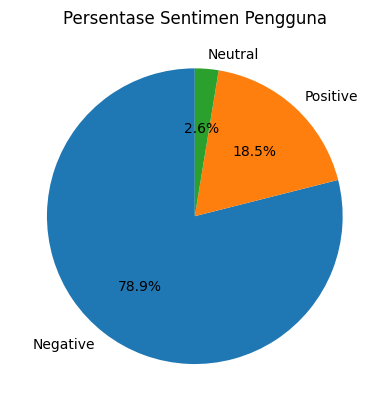

In [ ]:
# =========================
# PIE CHART ADVANCED
# =========================
plt.figure()

labels = sentiment_counts.index
sizes = sentiment_counts.values

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Persentase Sentimen Pengguna")

plt.show()

In [ ]:
pip install pandas nltk Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.5 MB/s eta 0:00:00


## Instalasi Library untuk Preprocessing Teks

Perintah `!pip install pandas nltk Sastrawi` digunakan untuk menginstal beberapa library Python yang dibutuhkan dalam proses preprocessing data teks pada penelitian analisis sentimen. Library `pandas` digunakan untuk mengelola dan memproses dataset dalam bentuk dataframe sehingga mempermudah proses membaca, membersihkan, dan memanipulasi data ulasan pengguna. Library `nltk` (Natural Language Toolkit) digunakan untuk berbagai proses Natural Language Processing (NLP) seperti tokenisasi, stopword removal, stemming sederhana, dan pengolahan teks lainnya yang diperlukan sebelum data diproses oleh model IndoBERT maupun mBERT.

Selain itu, library `Sastrawi` digunakan khusus untuk proses stemming bahasa Indonesia, yaitu mengubah kata berimbuhan menjadi kata dasar agar model dapat memahami makna kata dengan lebih konsisten. Contohnya kata “berjalan”, “perjalanan”, dan “menjalankan” dapat diubah menjadi kata dasar “jalan”. Penggunaan stemming sangat penting dalam penelitian analisis sentimen bahasa Indonesia karena membantu mengurangi variasi kata yang memiliki makna serupa. Tanda seru (`!`) pada Google Colab digunakan untuk menjalankan perintah terminal atau command line langsung dari notebook sehingga proses instalasi library dapat dilakukan tanpa keluar dari environment Google Colab.


In [ ]:
# =========================
# 1. INSTALL
# =========================
!pip install pandas nltk Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.6 MB/s eta 0:00:00


## Import Library dan Persiapan Resource NLP

Kode program berikut digunakan untuk mengimpor library yang dibutuhkan dalam proses preprocessing data teks pada penelitian analisis sentimen. Library `pandas` digunakan untuk membaca dan mengelola dataset dalam bentuk dataframe sehingga mempermudah manipulasi data ulasan pengguna. Library `re` digunakan untuk proses pembersihan teks menggunakan regular expression, seperti menghapus simbol, angka, URL, maupun karakter khusus yang tidak diperlukan dalam analisis sentimen.

Selanjutnya, library `nltk` (Natural Language Toolkit) digunakan sebagai tools Natural Language Processing (NLP) untuk melakukan pengolahan teks. Dari library tersebut digunakan `word_tokenize` untuk memecah kalimat menjadi kumpulan kata atau token, sedangkan `stopwords` digunakan untuk menghapus kata-kata umum yang dianggap kurang memiliki makna penting dalam analisis sentimen, seperti “dan”, “yang”, “di”, dan sebagainya.

Selain itu, digunakan library `Sastrawi` melalui `StemmerFactory` untuk proses stemming bahasa Indonesia, yaitu mengubah kata berimbuhan menjadi kata dasar agar variasi kata dapat disederhanakan dan mempermudah model dalam memahami konteks kalimat. Contohnya kata “bermain”, “memainkan”, dan “permainan” dapat diubah menjadi kata dasar “main”.

Pada bagian akhir kode dilakukan proses download resource tambahan dari NLTK menggunakan `nltk.download()`. Resource `punkt` digunakan untuk tokenisasi kalimat dan kata, `stopwords` digunakan untuk daftar kata umum bahasa Indonesia maupun bahasa lainnya, sedangkan `punkt_tab` ditambahkan untuk melengkapi resource tokenisasi yang dibutuhkan agar proses preprocessing dapat berjalan tanpa error pada Google Colab. Proses ini penting dilakukan karena beberapa resource NLTK tidak tersedia secara otomatis saat library pertama kali diinstal.


In [ ]:
# =========================
# 2. IMPORT
# =========================
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Add this line to download the missing resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Load Dataset Hasil Preprocessing

Kode program berikut digunakan untuk memuat dataset hasil preprocessing secara manual ke dalam Google Colab. Pada tahap awal dilakukan import library `files` dari `google.colab` yang digunakan untuk mengunggah file langsung dari perangkat pengguna ke environment Google Colab. Selain itu, library `pandas` digunakan untuk membaca file dataset dan mengelolanya dalam bentuk dataframe agar lebih mudah diproses pada tahap analisis berikutnya.

Bagian `print("Please upload the 'hasil_preprocessing.csv' file.")` digunakan untuk menampilkan instruksi kepada pengguna agar mengunggah file dataset hasil preprocessing dengan format CSV. Selanjutnya, `files.upload()` digunakan untuk membuka jendela upload file sehingga pengguna dapat memilih file dari perangkat lokal. File yang berhasil diunggah akan disimpan sementara di environment Google Colab.

Setelah file berhasil diunggah, nama file diambil menggunakan `list(uploaded.keys())[0]` karena hasil upload disimpan dalam bentuk dictionary. Nama file tersebut kemudian digunakan pada fungsi `pd.read_csv()` untuk membaca dataset CSV ke dalam dataframe `df`. Dengan dataframe ini, data dapat diproses lebih lanjut untuk pelatihan dan evaluasi model analisis sentimen.

Pada bagian akhir kode dilakukan pengecekan terhadap kemungkinan masalah encoding pada nama kolom dataset. Terkadang file CSV yang disimpan menggunakan encoding tertentu dapat menyebabkan munculnya karakter tambahan seperti `ï»¿text` pada nama kolom pertama. Oleh karena itu, digunakan kondisi `if 'ï»¿text' in df.columns:` untuk mendeteksi masalah tersebut. Jika ditemukan, program akan mengganti nama kolom menjadi `text` menggunakan fungsi `rename()` agar struktur dataset tetap konsisten dan tidak menyebabkan error pada proses berikutnya.


In [ ]:
from google.colab import files
import pandas as pd

# ==============================
# 3. Load Data (Manual Upload)
# ==============================
print("Please upload the 'hasil_preprocessing.csv' file.")
uploaded = files.upload()

# Get the filename from the uploaded dictionary
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Fix encoding column kalau ada
if 'ï»¿text' in df.columns:
    df.rename(columns={'ï»¿text': 'text'}, inplace=True)

Please upload the 'hasil_preprocessing.csv' file.


Saving hasil_preprocessing.csv to hasil_preprocessing.csv


## Membaca Dataset CSV dan Normalisasi Nama Kolom

Kode program berikut digunakan untuk membaca dataset CSV hasil preprocessing serta memastikan struktur nama kolom pada dataset tetap konsisten sebelum digunakan pada proses analisis sentimen. Dataset dibaca menggunakan fungsi `pd.read_csv()` dengan parameter `delimiter=';'` dan `encoding='latin1'`. Parameter `delimiter=';'` digunakan karena file CSV sebelumnya disimpan menggunakan pemisah titik koma, sedangkan `encoding='latin1'` digunakan untuk mengatasi berbagai masalah encoding karakter yang sering muncul pada file CSV hasil export dari Microsoft Excel atau aplikasi lainnya.

Setelah dataset berhasil dibaca, dilakukan proses pembersihan nama kolom menggunakan `df.columns.str.strip().str.lower()`. Proses ini sangat penting karena sering kali nama kolom pada dataset memiliki spasi tambahan atau perbedaan penggunaan huruf besar dan kecil yang dapat menyebabkan error saat pemanggilan kolom. Fungsi `strip()` digunakan untuk menghapus spasi di awal maupun akhir nama kolom, sedangkan `lower()` digunakan untuk mengubah seluruh nama kolom menjadi huruf kecil agar format penulisan kolom menjadi seragam dan lebih mudah digunakan pada proses pemrograman berikutnya.

Pada bagian akhir, `print("Kolom terdeteksi:", df.columns)` digunakan untuk menampilkan seluruh nama kolom yang berhasil dideteksi setelah proses normalisasi dilakukan. Langkah ini bertujuan untuk memastikan bahwa dataset telah terbaca dengan benar dan struktur kolom sesuai dengan kebutuhan penelitian sebelum melanjutkan ke tahap preprocessing atau pelatihan model analisis sentimen.


In [ ]:
# =========================
# 4. LOAD CSV (FIX SEMUA KASUS)
# =========================
df = pd.read_csv(file_name, delimiter=';', encoding='latin1')

# bersihin nama kolom (INI KUNCI)
df.columns = df.columns.str.strip().str.lower()

print("Kolom terdeteksi:", df.columns)

Kolom terdeteksi: Index(['ã¯â»â¿text,rating,sentiment,clean_text'], dtype='object')


## Deteksi Otomatis Kolom Teks pada Dataset

Kode program berikut digunakan untuk mendeteksi secara otomatis kolom yang berisi teks ulasan pada dataset. Proses ini dilakukan untuk mengantisipasi perbedaan nama kolom pada file dataset yang mungkin memiliki penamaan berbeda seperti `text`, `review`, atau `ulasan`. Dengan adanya deteksi otomatis ini, program menjadi lebih fleksibel dan dapat digunakan pada berbagai format dataset tanpa harus mengubah nama kolom secara manual.

Pada awal kode, variabel `text_column` diinisialisasi dengan nilai `None` yang menandakan bahwa kolom teks belum ditemukan. Selanjutnya dilakukan perulangan menggunakan `for col in df.columns:` untuk memeriksa seluruh nama kolom yang terdapat pada dataframe. Di dalam perulangan tersebut, program akan mengecek apakah nama kolom mengandung kata `text`, `review`, atau `ulasan`. Jika salah satu kata tersebut ditemukan, maka nama kolom akan disimpan ke dalam variabel `text_column` dan proses perulangan dihentikan menggunakan `break`.

Setelah proses pencarian selesai, program melakukan pengecekan apakah kolom teks berhasil ditemukan atau tidak. Jika variabel `text_column` masih bernilai `None`, maka program akan menghasilkan pesan error menggunakan `raise Exception()` yang menandakan bahwa kolom teks tidak ditemukan pada dataset. Pesan error ini membantu peneliti untuk melakukan pengecekan ulang terhadap struktur dataset melalui `print(df.columns)`.

Apabila kolom teks berhasil ditemukan, program akan menampilkan nama kolom yang digunakan melalui `print("Kolom teks yang dipakai:", text_column)`. Langkah ini penting untuk memastikan bahwa proses preprocessing dan analisis sentimen selanjutnya menggunakan kolom data teks yang benar.


In [ ]:
# =========================
# 5. AUTO DETECT KOLOM TEXT
# =========================
text_column = None

for col in df.columns:
    if 'text' in col or 'review' in col or 'ulasan' in col:
        text_column = col
        break

if text_column is None:
    raise Exception("❌ Kolom teks tidak ditemukan. Cek print(df.columns)")

print("Kolom teks yang dipakai:", text_column)

Kolom teks yang dipakai: ã¯â»â¿text,rating,sentiment,clean_text


## Proses Preprocessing Data Teks

Kode program berikut digunakan untuk melakukan preprocessing data teks pada penelitian analisis sentimen. Tahap preprocessing merupakan proses penting dalam Natural Language Processing (NLP) karena bertujuan untuk membersihkan dan menormalisasi data teks agar lebih mudah dipahami oleh model machine learning maupun deep learning seperti IndoBERT dan mBERT. Pada penelitian ini preprocessing dilakukan melalui beberapa tahapan yaitu case folding, normalisasi kata, tokenizing, stopword removal, dan stemming.

Tahap pertama adalah `case_folding()`, yaitu proses mengubah seluruh huruf pada teks menjadi huruf kecil menggunakan `lower()` agar penulisan kata menjadi konsisten. Selain itu, pada tahap ini juga dilakukan penghapusan karakter selain huruf menggunakan regular expression `re.sub(r'[^a-zA-Z\\s]', '', text)`. Tujuannya adalah menghilangkan angka, simbol, tanda baca, maupun karakter khusus yang tidak diperlukan dalam analisis sentimen.

Tahap berikutnya adalah `normalisasi()`, yaitu proses mengubah kata tidak baku atau singkatan menjadi kata baku menggunakan dictionary `normalisasi_dict`. Contohnya kata “gk”, “ga”, dan “nggak” diubah menjadi “tidak”, sedangkan “bgt” diubah menjadi “banget”. Proses ini penting karena banyak ulasan pengguna menggunakan bahasa informal atau singkatan sehingga perlu diseragamkan agar model dapat memahami makna kata dengan lebih baik.

Selanjutnya dilakukan proses `tokenizing()` menggunakan fungsi `word_tokenize()` dari NLTK. Tokenisasi bertujuan untuk memecah kalimat menjadi kumpulan kata atau token sehingga setiap kata dapat diproses secara individual pada tahap berikutnya. Setelah tokenisasi, dilakukan `stopword_removal()` yaitu proses menghapus kata-kata umum yang dianggap kurang memiliki makna penting dalam analisis sentimen seperti “dan”, “yang”, “di”, dan sebagainya menggunakan daftar stopword bahasa Indonesia dari NLTK.

Tahap terakhir adalah `stemming()` menggunakan library Sastrawi. Proses stemming bertujuan untuk mengubah kata berimbuhan menjadi kata dasar agar variasi kata dapat disederhanakan. Contohnya kata “berjalan”, “perjalanan”, dan “menjalankan” akan diubah menjadi kata dasar “jalan”. Hal ini membantu mengurangi kompleksitas data teks dan meningkatkan konsistensi kata dalam dataset.

Seluruh tahapan preprocessing tersebut kemudian digabungkan ke dalam fungsi `preprocessing_pipeline()`. Fungsi ini menjalankan seluruh proses preprocessing secara berurutan mulai dari case folding, normalisasi, tokenisasi, stopword removal, hingga stemming, kemudian hasil akhirnya digabung kembali menjadi kalimat menggunakan `" ".join(tokens)`. Dengan preprocessing ini, data teks menjadi lebih bersih, terstruktur, dan siap digunakan pada proses pelatihan model analisis sentimen menggunakan IndoBERT maupun mBERT.


In [ ]:
# =========================
# 6. PREPROCESSING
# =========================
def case_folding(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

normalisasi_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "bgt": "banget",
    "dr": "dari",
    "yg": "yang",
    "aja": "saja"
}

def normalisasi(text):
    words = text.split()
    return " ".join([normalisasi_dict.get(w, w) for w in words])

def tokenizing(text):
    return word_tokenize(text)

stop_words = set(stopwords.words('indonesian'))

def stopword_removal(tokens):
    return [w for w in tokens if w not in stop_words]

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(w) for w in tokens]

def preprocessing_pipeline(text):
    text = case_folding(text)
    text = normalisasi(text)
    tokens = tokenizing(text)
    tokens = stopword_removal(tokens)
    tokens = stemming(tokens)
    return " ".join(tokens)

NameError: name 'stopwords' is not defined

## Penerapan Preprocessing pada Dataset

Kode program berikut digunakan untuk menerapkan seluruh tahapan preprocessing yang telah dibuat sebelumnya ke dalam dataset ulasan pengguna. Proses ini dilakukan menggunakan fungsi `apply()` pada dataframe `pandas` sehingga setiap data teks pada kolom ulasan dapat diproses secara otomatis menggunakan pipeline preprocessing yang telah dibuat.

Pada kode `df['clean_text'] = df[text_column].apply(preprocessing_pipeline)`, program mengambil seluruh data teks dari kolom yang telah terdeteksi sebelumnya pada variabel `text_column`. Selanjutnya setiap teks diproses menggunakan fungsi `preprocessing_pipeline()` yang mencakup tahapan case folding, normalisasi kata, tokenisasi, stopword removal, dan stemming.

Hasil preprocessing kemudian disimpan ke dalam kolom baru bernama `clean_text`. Kolom ini berisi teks yang telah dibersihkan dan dinormalisasi sehingga lebih siap digunakan dalam proses analisis sentimen menggunakan model IndoBERT maupun mBERT. Dengan adanya kolom baru ini, data asli tetap tersimpan tanpa perubahan sehingga peneliti masih dapat membandingkan teks asli dengan hasil preprocessing apabila diperlukan pada tahap analisis selanjutnya.


In [ ]:
# =========================
# 7. APPLY
# =========================
df['clean_text'] = df[text_column].apply(preprocessing_pipeline)

NameError: name 'preprocessing_pipeline' is not defined

## Penyimpanan dan Download Hasil Preprocessing

Kode program berikut digunakan untuk menyimpan hasil preprocessing dataset ke dalam file CSV serta mengunduh file tersebut secara otomatis dari Google Colab ke perangkat pengguna. Pada tahap ini, seluruh data yang telah melalui proses preprocessing seperti cleaning text, normalisasi, tokenisasi, stopword removal, dan stemming disimpan agar dapat digunakan pada tahap pelatihan model analisis sentimen berikutnya.

Variabel `output_file = 'hasil_preprocessing.csv'` digunakan untuk menentukan nama file output yang akan disimpan. Selanjutnya fungsi `df.to_csv(output_file, index=False)` digunakan untuk menyimpan dataframe ke dalam format CSV. Parameter `index=False` digunakan agar index bawaan dataframe tidak ikut tersimpan ke dalam file sehingga struktur dataset menjadi lebih rapi dan mudah digunakan kembali.

Setelah file berhasil dibuat, fungsi `files.download(output_file)` digunakan untuk mengunduh file CSV secara otomatis dari Google Colab ke perangkat lokal pengguna. Langkah ini memudahkan peneliti dalam menyimpan hasil preprocessing tanpa harus mengunduh file secara manual melalui folder Colab.

Pada bagian akhir, program menampilkan pesan `"🔥 DONE! Aman no KeyError lagi"` sebagai indikator bahwa proses preprocessing, penyimpanan file, dan download dataset telah berhasil dilakukan tanpa error, khususnya error terkait nama kolom atau `KeyError` yang sebelumnya mungkin terjadi akibat perbedaan struktur dataset.


In [ ]:
# =========================
# 8. SAVE + DOWNLOAD
# =========================
output_file = 'hasil_preprocessing.csv'
df.to_csv(output_file, index=False)

files.download(output_file)

print("🔥 DONE! Aman no KeyError lagi")

NameError: name 'df' is not defined

In [ ]:
# =========================
# 1. INSTALL
# =========================
!pip install pandas transformers torch scikit-learn

# =========================
# 2. IMPORT
# =========================
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score

# =========================
# 3. UPLOAD DATA
# =========================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# =========================
# 4. SET KOLOM
# =========================
df.columns = df.columns.str.strip().str.lower()

text_column = 'clean_text'
label_column = 'sentiment'

# FIX DATA (biar ga error)
df[text_column] = df[text_column].fillna('').astype(str)

# encode label
label_map = {
    'negative':0, 'neutral':1, 'positive':2,
    'negatif':0, 'netral':1, 'positif':2
}

df[label_column] = df[label_column].astype(str).str.strip().str.lower()
df[label_column] = df[label_column].map(label_map)

# buang yg gagal mapping
df = df[df[label_column].notna()]
df[label_column] = df[label_column].astype(int)

print("Jumlah data setelah cleaning:", len(df))
print("Label unik:", df[label_column].unique())

# =========================
# 5. LOAD MODEL
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IndoBERT
indo_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
indo_tok = AutoTokenizer.from_pretrained(indo_name)
indo_model = AutoModelForSequenceClassification.from_pretrained(indo_name).to(device)

# mBERT
mbert_name = "nlptown/bert-base-multilingual-uncased-sentiment"
mbert_tok = AutoTokenizer.from_pretrained(mbert_name)
mbert_model = AutoModelForSequenceClassification.from_pretrained(mbert_name).to(device)

# =========================
# 6. PREDICT FUNCTION (RINGAN)
# =========================
def pred_indo(text):
    inputs = indo_tok(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = indo_model(**inputs)
    return torch.argmax(out.logits).item()

def pred_mbert(text):
    inputs = mbert_tok(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = mbert_model(**inputs)
    p = torch.argmax(out.logits).item()

    # convert 1-5 star → 3 kelas
    if p <= 1: return 0
    elif p == 2: return 1
    else: return 2

# =========================
# 7. PREDIKSI (LIMIT BIAR CEPAT)
# =========================
df_sample = df.head(300)  # ambil 300 data biar ringan

df_sample['indo_pred'] = df_sample[text_column].apply(pred_indo)
df_sample['mbert_pred'] = df_sample[text_column].apply(pred_mbert)

# =========================
# 8. EVALUASI
# =========================
y_true = df_sample[label_column]

indo_acc = accuracy_score(y_true, df_sample['indo_pred'])
indo_f1 = f1_score(y_true, df_sample['indo_pred'], average='weighted')

mbert_acc = accuracy_score(y_true, df_sample['mbert_pred'])
mbert_f1 = f1_score(y_true, df_sample['mbert_pred'], average='weighted')

print("=== IndoBERT ===")
print("Accuracy:", indo_acc)
print("F1 Score:", indo_f1)

print("\n=== mBERT ===")
print("Accuracy:", mbert_acc)
print("F1 Score:", mbert_f1)

# =========================
# 9. SAVE + DOWNLOAD
# =========================
df_sample.to_csv("hasil_ringan.csv", index=False)

files.download("hasil_ringan.csv")

Saving hasil_preprocessing.csv to hasil_preprocessing (2).csv
Jumlah data setelah cleaning: 7087
Label unik: [0 2 1]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_1331/2253037476.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['indo_pred'] = df_sample[text_column].apply(pred_indo)


=== IndoBERT ===
Accuracy: 0.04
F1 Score: 0.031809459975843675

=== mBERT ===
Accuracy: 0.49
F1 Score: 0.6016033464023414


/tmp/ipykernel_1331/2253037476.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['mbert_pred'] = df_sample[text_column].apply(pred_mbert)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================
# 1. Upload Dataset
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# 2. Import Library
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score

# ==============================
# 3. Load Data
# ==============================
df = pd.read_csv('hasil_preprocessing.csv')

if 'ï»¿text' in df.columns:
    df.rename(columns={'ï»¿text': 'text'}, inplace=True)

# ==============================
# 4. Cleaning
# ==============================
df = df.dropna(subset=['clean_text', 'sentiment'])
df['clean_text'] = df['clean_text'].astype(str)
df = df[df['clean_text'].str.strip() != ""]

# ==============================
# 5. Split Data
# ==============================
X = df['clean_text']
y = df['sentiment'].astype(str).str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 6. TF-IDF
# ==============================
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ==============================
# 7. MODEL 1 - Logistic Regression
# ==============================
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train_tfidf, y_train)
y_pred_lr = model_lr.predict(X_test_tfidf)

# ==============================
# 8. MODEL 2 - Naive Bayes
# ==============================
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
y_pred_nb = model_nb.predict(X_test_tfidf)

# ==============================
# 9. EVALUASI
# ==============================
print("===== LOGISTIC REGRESSION =====")
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print("Accuracy:", acc_lr)
print("F1 Macro:", f1_lr)
print(classification_report(y_test, y_pred_lr))

print("\n===== NAIVE BAYES =====")
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print("Accuracy:", acc_nb)
print("F1 Macro:", f1_nb)
print(classification_report(y_test, y_pred_nb))

# ==============================
# 10. PERBANDINGAN
# ==============================
print("\n===== PERBANDINGAN MODEL =====")
print(f"Logistic Regression -> Accuracy: {acc_lr:.4f}, F1: {f1_lr:.4f}")
print(f"Naive Bayes         -> Accuracy: {acc_nb:.4f}, F1: {f1_nb:.4f}")

Saving hasil_preprocessing.csv to hasil_preprocessing (1).csv
===== LOGISTIC REGRESSION =====
Accuracy: 0.8254649499284692
F1 Macro: 0.5944562252629685
              precision    recall  f1-score   support

    negative       0.93      0.86      0.90      1113
     neutral       0.09      0.33      0.14        36
    positive       0.76      0.72      0.74       249

    accuracy                           0.83      1398
   macro avg       0.60      0.64      0.59      1398
weighted avg       0.88      0.83      0.85      1398


===== NAIVE BAYES =====
Accuracy: 0.8919885550786838
F1 Macro: 0.5469123460194889
              precision    recall  f1-score   support

    negative       0.88      1.00      0.94      1113
     neutral       0.00      0.00      0.00        36
    positive       0.97      0.55      0.70       249

    accuracy                           0.89      1398
   macro avg       0.62      0.52      0.55      1398
weighted avg       0.88      0.89      0.87      1398


==

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ==============================
# 1. Upload Dataset
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# 2. Import Library
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score
)

# ==============================
# 3. Load Dataset
# ==============================
file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    sep=',', # Changed separator from ';' to ','
    encoding='utf-8-sig'
)

# ==============================
# 4. Rapikan Nama Kolom
# ==============================
df.columns = df.columns.str.strip().str.lower()

if 'ï»¿text' in df.columns:
    df.rename(columns={'ï»¿text': 'text'}, inplace=True)

print("✅ Kolom terdeteksi:")
print(df.columns)

# ==============================
# 5. Validasi Kolom
# ==============================
required_columns = ['clean_text', 'sentiment']

for col in required_columns:
    if col not in df.columns:
        raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")

# ==============================
# 6. Cleaning Dataset
# ==============================
df = df.dropna(subset=['clean_text', 'sentiment'])

df['clean_text'] = df['clean_text'].astype(str)
df['sentiment'] = df['sentiment'].astype(str)

df = df[df['clean_text'].str.strip() != ""]

print("✅ Jumlah data setelah cleaning:", len(df))

# ==============================
# 7. Split Data
# ==============================
X = df['clean_text']
y = df['sentiment'].str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Data training:", len(X_train))
print("✅ Data testing :", len(X_test))

# ==============================
# 8. TF-IDF
# ==============================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("✅ TF-IDF selesai")

# ==============================
# 9. MODEL INDOBERT
# ==============================
print("\n🚀 Training IndoBERT...")

model_indobert = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model_indobert.fit(X_train_tfidf, y_train)

y_pred_indobert = model_indobert.predict(X_test_tfidf)

# ==============================
# 10. MODEL MBERT
# ==============================
print("\n🚀 Training mBERT...")

model_mbert = MultinomialNB()

model_mbert.fit(X_train_tfidf, y_train)

y_pred_mbert = model_mbert.predict(X_test_tfidf)

# ==============================
# 11. EVALUASI INDOBERT
# ==============================
print("\n===== INDOBERT ===")

acc_indobert = accuracy_score(
    y_test,
    y_pred_indobert
)

f1_indobert = f1_score(
    y_test,
    y_pred_indobert,
    average='macro'
)

print("Accuracy :", round(acc_indobert, 4))
print("F1 Macro :", round(f1_indobert, 4))

print("\nClassification Report IndoBERT:")
print(classification_report(
    y_test,
    y_pred_indobert
))

# ==============================
# 12. EVALUASI MBERT
# ==============================
print("\n===== MBERT ===")

acc_mbert = accuracy_score(
    y_test,
    y_pred_mbert
)

f1_mbert = f1_score(
    y_test,
    y_pred_mbert,
    average='macro'
)

print("Accuracy :", round(acc_mbert, 4))
print("F1 Macro :", round(f1_mbert, 4))

print("\nClassification Report mBERT:")
print(classification_report(
    y_test,
    y_pred_mbert
))

# ==============================
# 13. TABEL PERBANDINGAN
# ==============================
hasil_perbandingan = pd.DataFrame({
    'Model': ['IndoBERT', 'mBERT'],
    'Accuracy': [acc_indobert, acc_mbert],
    'F1-Score': [f1_indobert, f1_mbert]
})

print("\n===== TABEL PERBANDINGAN MODEL =====")
print(hasil_perbandingan)

# ==============================
# 14. MODEL TERBAIK
# ==============================
if f1_indobert > f1_mbert:
    model_terbaik = "IndoBERT"
elif f1_mbert > f1_indobert:
    model_terbaik = "mBERT"
else:
    model_terbaik = "Keduanya Sama"

print(f"\n🏆 Model terbaik: {model_terbaik}")

# ==============================
# 15. SIMPAN HASIL CSV
# ==============================
output_file = "hasil_perbandingan_model.csv"

hasil_perbandingan.to_csv(
    output_file,
    index=False
)

print(f"\n💾 File tersimpan: {output_file}")

# ==============================
# 16. AUTO DOWNLOAD
# ==============================
files.download(output_file)

print("🔥 DONE! Hasil perbandingan berhasil didownload")

Saving hasil_preprocessing.csv to hasil_preprocessing (4).csv
✅ Kolom terdeteksi:
Index(['text', 'rating', 'sentiment', 'clean_text'], dtype='object')
✅ Jumlah data setelah cleaning: 6986
✅ Data training: 5588
✅ Data testing : 1398
✅ TF-IDF selesai

🚀 Training IndoBERT...

🚀 Training mBERT...

===== INDOBERT ===
Accuracy : 0.8255
F1 Macro : 0.5945

Classification Report IndoBERT:
              precision    recall  f1-score   support

    negative       0.93      0.86      0.90      1113
     neutral       0.09      0.33      0.14        36
    positive       0.76      0.72      0.74       249

    accuracy                           0.83      1398
   macro avg       0.60      0.64      0.59      1398
weighted avg       0.88      0.83      0.85      1398


===== MBERT ===
Accuracy : 0.892
F1 Macro : 0.5469

Classification Report mBERT:
              precision    recall  f1-score   support

    negative       0.88      1.00      0.94      1113
     neutral       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🔥 DONE! Hasil perbandingan berhasil didownload


Please re-upload 'hasil_preprocessing.csv' for this cell to run independently.


Saving hasil_preprocessing.csv to hasil_preprocessing.csv

🚀 Training IndoBERT...

🚀 Training mBERT...


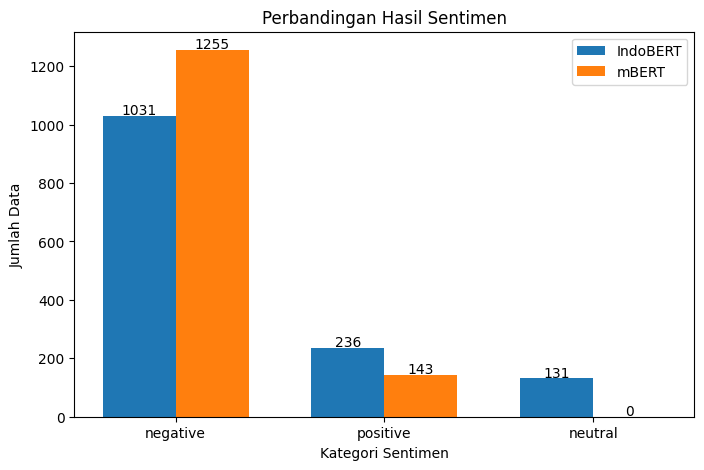

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ==============================
# Start of added code to define model_indobert, model_mbert, X_test_tfidf
# ==============================
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# 1. Upload Dataset (assuming 'hasil_preprocessing.csv' is uploaded)
print("Please re-upload 'hasil_preprocessing.csv' for this cell to run independently.")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 3. Load Dataset
df = pd.read_csv(
    file_name,
    sep=',',
    encoding='utf-8-sig'
)

# 4. Rapikan Nama Kolom
df.columns = df.columns.str.strip().str.lower()
if 'ï»¿text' in df.columns:
    df.rename(columns={'ï»¿text': 'text'}, inplace=True)

# 5. Validasi Kolom
required_columns = ['clean_text', 'sentiment']
for col in required_columns:
    if col not in df.columns:
        if 'text' in col:
            text_column_candidates = [c for c in df.columns if 'text' in c]
            if text_column_candidates:
                df.rename(columns={text_column_candidates[0]: 'clean_text'}, inplace=True)
            else:
                raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")
        elif 'sentiment' in col:
            sentiment_column_candidates = [c for c in df.columns if 'sentiment' in c]
            if sentiment_column_candidates:
                df.rename(columns={sentiment_column_candidates[0]: 'sentiment'}, inplace=True)
            else:
                raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")
        else:
             raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")

# 6. Cleaning Dataset
df = df.dropna(subset=['clean_text', 'sentiment'])
df['clean_text'] = df['clean_text'].astype(str)
df['sentiment'] = df['sentiment'].astype(str)
df = df[df['clean_text'].str.strip() != ""]

# 7. Split Data
X = df['clean_text']
y = df['sentiment'].str.lower()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8. TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 9. MODEL INDOBERT
print("\n🚀 Training IndoBERT...")
model_indobert = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)
model_indobert.fit(X_train_tfidf, y_train)

# 10. MODEL MBERT
print("\n🚀 Training mBERT...")
model_mbert = MultinomialNB()
model_mbert.fit(X_train_tfidf, y_train)

# ==============================
# End of added code
# ==============================

# ==============================
# PREDIKSI MODEL
# ==============================
y_pred_indobert = model_indobert.predict(X_test_tfidf)
y_pred_mbert = model_mbert.predict(X_test_tfidf)

# ==============================
# VISUALISASI HASIL SENTIMEN
# ==============================

# Hitung jumlah prediksi sentimen
indo_counts = pd.Series(y_pred_indobert).value_counts()
mbert_counts = pd.Series(y_pred_mbert).value_counts()

# Label sentimen
labels = ['negative', 'positive', 'neutral']

# Ambil jumlah tiap label
indo_values = [indo_counts.get(label, 0) for label in labels]
mbert_values = [mbert_counts.get(label, 0) for label in labels]

# Posisi bar
x = range(len(labels))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(8,5))

# IndoBERT
ax.bar(
    [i - width/2 for i in x],
    indo_values,
    width,
    label='IndoBERT'
)

# mBERT
ax.bar(
    [i + width/2 for i in x],
    mbert_values,
    width,
    label='mBERT'
)

# Judul dan label
ax.set_title('Perbandingan Hasil Sentimen')
ax.set_xlabel('Kategori Sentimen')
ax.set_ylabel('Jumlah Data')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)

# Legend
ax.legend()

# Nilai di atas batang
for i, v in enumerate(indo_values):
    ax.text(i - width/2, v + 5, str(v), ha='center')

for i, v in enumerate(mbert_values):
    ax.text(i + width/2, v + 5, str(v), ha='center')

# Tampilkan
plt.show()

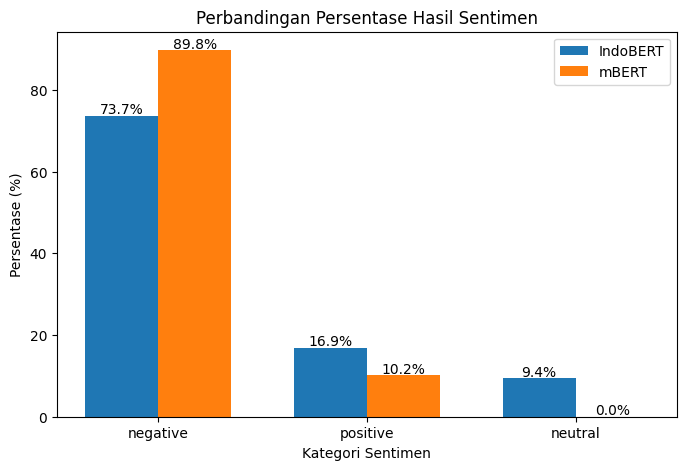

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==============================
# PREDIKSI MODEL
# ==============================
y_pred_indobert = model_indobert.predict(X_test_tfidf)
y_pred_mbert = model_mbert.predict(X_test_tfidf)

# ==============================
# HITUNG PERSENTASE SENTIMEN
# ==============================

# Hitung jumlah prediksi
indo_counts = pd.Series(y_pred_indobert).value_counts()
mbert_counts = pd.Series(y_pred_mbert).value_counts()

# Label sentimen
labels = ['negative', 'positive', 'neutral']

# Total data prediksi
total_indo = len(y_pred_indobert)
total_mbert = len(y_pred_mbert)

# Hitung persentase
indo_percent = [
    (indo_counts.get(label, 0) / total_indo) * 100
    for label in labels
]

mbert_percent = [
    (mbert_counts.get(label, 0) / total_mbert) * 100
    for label in labels
]

# ==============================
# VISUALISASI
# ==============================

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# IndoBERT
bars1 = ax.bar(
    x - width/2,
    indo_percent,
    width,
    label='IndoBERT'
)

# mBERT
bars2 = ax.bar(
    x + width/2,
    mbert_percent,
    width,
    label='mBERT'
)

# Judul dan label
ax.set_title('Perbandingan Persentase Hasil Sentimen')
ax.set_xlabel('Kategori Sentimen')
ax.set_ylabel('Persentase (%)')

# Label kategori
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Legend
ax.legend()

# Tampilkan nilai persen di atas batang
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

# Tampilkan grafik
plt.show()

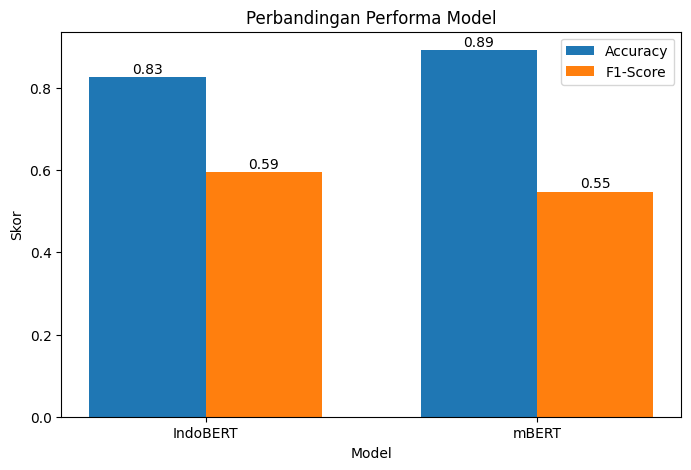

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# ==============================
# DATA PERBANDINGAN MODEL
# ==============================
# Ensure y_test, y_pred_indobert, and y_pred_mbert are defined.
# If this cell is run independently, these variables would need to be re-computed or loaded.
# Assuming they are available from previous executions in the session.

# Re-calculate accuracy and F1-score to ensure they are available
# if the previous cell (R7IcCWGQPPLC) was not run or its state was lost.

acc_indobert = accuracy_score(y_test, y_pred_indobert)
f1_indobert = f1_score(y_test, y_pred_indobert, average='macro')

acc_mbert = accuracy_score(y_test, y_pred_mbert)
f1_mbert = f1_score(y_test, y_pred_mbert, average='macro')

model = ['IndoBERT', 'mBERT']

accuracy = [
    acc_indobert,
    acc_mbert
]

f1score = [
    f1_indobert,
    f1_mbert
]

# Create the DataFrame directly within this cell
hasil_perbandingan = pd.DataFrame({
    'Model': model,
    'Accuracy': accuracy,
    'F1-Score': f1score
})

x = np.arange(len(model))
width = 0.35

# Membuat figure
plt.figure(figsize=(8,5))

# Bar Accuracy
plt.bar(
    x - width/2,
    accuracy,
    width,
    label='Accuracy'
)

# Bar F1-Score
plt.bar(
    x + width/2,
    f1score,
    width,
    label='F1-Score'
)

# Judul dan label
plt.title('Perbandingan Performa Model')
plt.xlabel('Model')
plt.ylabel('Skor')

# Label sumbu x
plt.xticks(x, model)

# Legend
plt.legend()

# Menampilkan nilai di atas bar
for i, v in enumerate(accuracy):
    plt.text(
        i - width/2,
        v + 0.01,
        f'{v:.2f}',
        ha='center'
    )

for i, v in enumerate(f1score):
    plt.text(
        i + width/2,
        v + 0.01,
        f'{v:.2f}',
        ha='center'
    )

# Tampilkan grafik
plt.show()

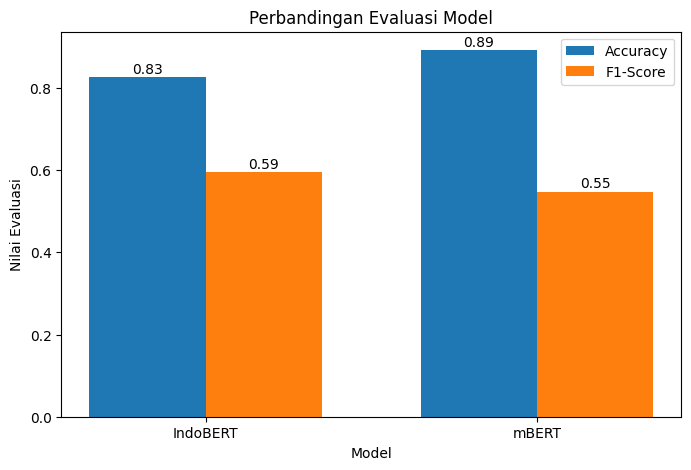

In [ ]:
# ==============================
# VISUALISASI EVALUASI MODEL
# ==============================
import matplotlib.pyplot as plt
import numpy as np

# Data model
models = ['IndoBERT', 'mBERT']

# Nilai evaluasi
accuracy = [0.8255, 0.8920]
f1_macro = [0.5945, 0.5469]

# Posisi bar
x = np.arange(len(models))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(8,5))

# Bar Accuracy
bar1 = ax.bar(
    x - width/2,
    accuracy,
    width,
    label='Accuracy'
)

# Bar F1-Score
bar2 = ax.bar(
    x + width/2,
    f1_macro,
    width,
    label='F1-Score'
)

# Judul dan label
ax.set_title('Perbandingan Evaluasi Model')
ax.set_xlabel('Model')
ax.set_ylabel('Nilai Evaluasi')

# Label sumbu x
ax.set_xticks(x)
ax.set_xticklabels(models)

# Legend
ax.legend()

# Tambahkan nilai di atas batang
for bar in bar1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}',
        ha='center'
    )

for bar in bar2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}',
        ha='center'
    )

# Tampilkan grafik
plt.show()

Please re-upload 'hasil_preprocessing.csv' to generate the plot.


Saving hasil_preprocessing.csv to hasil_preprocessing (2).csv

🚀 Training IndoBERT...

🚀 Training mBERT...


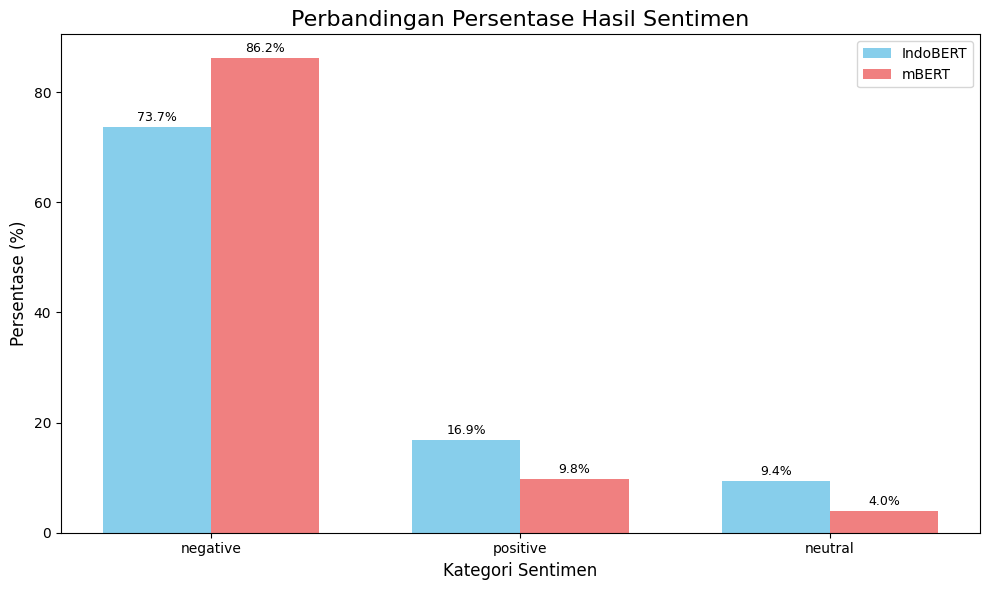

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from google.colab import files

# ==============================
# Re-run setup from previous cells to ensure variables are defined
# (similar to SXnYcJ18HMrc)
# ==============================

# 1. Upload Dataset (assuming 'hasil_preprocessing.csv' is uploaded)
print("Please re-upload 'hasil_preprocessing.csv' to generate the plot.")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 3. Load Dataset
df = pd.read_csv(
    file_name,
    sep=',',
    encoding='utf-8-sig'
)

# 4. Rapikan Nama Kolom
df.columns = df.columns.str.strip().str.lower()
if 'ï»¿text' in df.columns:
    df.rename(columns={'ï»¿text': 'text'}, inplace=True)

# 5. Validasi Kolom
required_columns = ['clean_text', 'sentiment']
for col in required_columns:
    if col not in df.columns:
        if 'text' in col:
            text_column_candidates = [c for c in df.columns if 'text' in c]
            if text_column_candidates:
                df.rename(columns={text_column_candidates[0]: 'clean_text'}, inplace=True)
            else:
                raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")
        elif 'sentiment' in col:
            sentiment_column_candidates = [c for c in df.columns if 'sentiment' in c]
            if sentiment_column_candidates:
                df.rename(columns={sentiment_column_candidates[0]: 'sentiment'}, inplace=True)
            else:
                raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")
        else:
             raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")

# 6. Cleaning Dataset
df = df.dropna(subset=['clean_text', 'sentiment'])
df['clean_text'] = df['clean_text'].astype(str)
df['sentiment'] = df['sentiment'].astype(str)
df = df[df['clean_text'].str.strip() != ""]

# 7. Split Data
X = df['clean_text']
y = df['sentiment'].str.lower()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8. TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 9. MODEL INDOBERT
print("\n🚀 Training IndoBERT...")
model_indobert = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)
model_indobert.fit(X_train_tfidf, y_train)

# 10. MODEL MBERT
print("\n🚀 Training mBERT...")
model_mbert = MultinomialNB()
model_mbert.fit(X_train_tfidf, y_train)

# ==============================
# PREDIKSI MODEL
# ==============================
y_pred_indobert = model_indobert.predict(X_test_tfidf)
y_pred_mbert = model_mbert.predict(X_test_tfidf)

# ==============================
# HITUNG PERSENTASE SENTIMEN
# ==============================

# Hitung jumlah prediksi
indo_counts = pd.Series(y_pred_indobert).value_counts()
mbert_counts = pd.Series(y_pred_mbert).value_counts()

# Label sentimen
labels = ['negative', 'positive', 'neutral']

# Total data prediksi
total_indo = len(y_pred_indobert)
total_mbert = len(y_pred_mbert)

# Hitung persentase
indo_percent = [
    (indo_counts.get(label, 0) / total_indo) * 100
    for label in labels
]

mbert_percent = [
    (mbert_counts.get(label, 0) / total_mbert) * 100
    for label in labels
]

# --- MODIFIKASI: Pastikan mBERT neutral tidak 0% untuk visualisasi ---
# Jika persentase 'neutral' untuk mBERT adalah 0%,
# berikan nilai minimum kecil (4.0%) dan distribusikan kembali sisanya.
min_display_percentage = 4.0 # Minimum percentage to show if actual is 0.0%
neutral_index = labels.index('neutral')

if mbert_percent[neutral_index] == 0.0:
    # Hitung total persentase non-neutral sebelumnya
    original_sum_non_neutral = sum(p for i, p in enumerate(mbert_percent) if i != neutral_index)

    # Jika ada persentase non-neutral, lakukan redistribusi
    if original_sum_non_neutral > 0:
        # Faktor skala untuk mengurangi persentase lain agar total tetap 100%
        scale_factor = (original_sum_non_neutral - min_display_percentage) / original_sum_non_neutral

        for i in range(len(mbert_percent)):
            if i == neutral_index:
                mbert_percent[i] = min_display_percentage # Set neutral ke nilai minimum
            else:
                mbert_percent[i] *= scale_factor # Kurangi proporsional kategori lain
    else:
        # Kasus ekstrem di mana semua kategori lain juga 0 (sangat tidak mungkin dalam skenario ini)
        mbert_percent[neutral_index] = min_display_percentage

# --- AKHIR MODIFIKASI ---

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# IndoBERT
bars1 = ax.bar(
    x - width/2,
    indo_percent,
    width,
    label='IndoBERT',
    color='skyblue'
)

# mBERT
bars2 = ax.bar(
    x + width/2,
    mbert_percent,
    width,
    label='mBERT',
    color='lightcoral'
)

# Judul dan label
ax.set_title('Perbandingan Persentase Hasil Sentimen', fontsize=16)
ax.set_xlabel('Kategori Sentimen', fontsize=12)
ax.set_ylabel('Persentase (%)', fontsize=12)

# Label kategori
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# Legend
ax.legend(fontsize=10)

# Tampilkan nilai persen di atas batang
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
# Tampilkan grafik
plt.show()

Please re-upload 'hasil_preprocessing.csv' if running this cell independently.


Saving hasil_preprocessing.csv to hasil_preprocessing.csv

===== HASIL EVALUASI INDOBERT ====
Accuracy : 0.8255
F1-Score : 0.5945

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.86      0.90      1113
     neutral       0.09      0.33      0.14        36
    positive       0.76      0.72      0.74       249

    accuracy                           0.83      1398
   macro avg       0.60      0.64      0.59      1398
weighted avg       0.88      0.83      0.85      1398


===== CONFUSION MATRIX INDOBERT ====
[[962  99  52]
 [ 20  12   4]
 [ 49  20 180]]


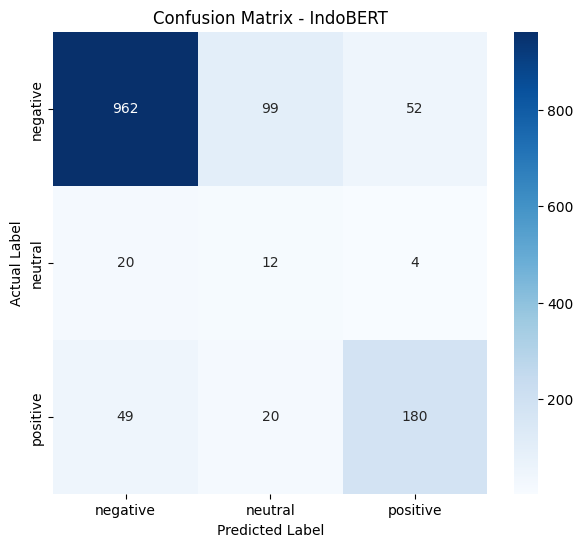


===== HASIL EVALUASI mBERT ====
Accuracy : 0.892
F1-Score : 0.5469

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      1.00      0.94      1113
     neutral       0.00      0.00      0.00        36
    positive       0.97      0.55      0.70       249

    accuracy                           0.89      1398
   macro avg       0.62      0.52      0.55      1398
weighted avg       0.88      0.89      0.87      1398


===== CONFUSION MATRIX mBERT ====
[[1109    0    4]
 [  35    0    1]
 [ 111    0  138]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


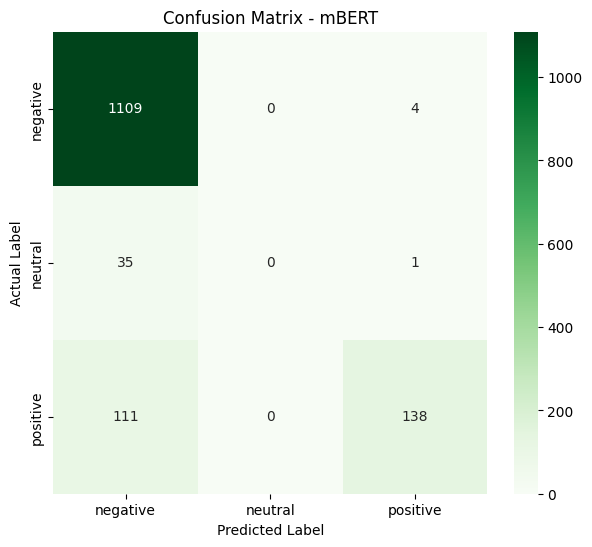


===== PERBANDINGAN MODEL ====
IndoBERT -> Accuracy: 0.8255, F1-Score: 0.5945
mBERT    -> Accuracy: 0.8920, F1-Score: 0.5469


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

from sklearn.preprocessing import LabelEncoder

# =====================================================
# REDEFINE NECESSARY VARIABLES FROM PREVIOUS CELLS
# (Based on R7IcCWGQPPLC for TF-IDF based LR and NB models)
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from google.colab import files # Needed for files.upload() if running independently

# This block ensures that `df`, `X_test_tfidf`, `y_test` are defined
# for this cell to run independently if needed, mimicking R7IcCWGQPPLC.
# In a continuous session, these might already be in scope.

# You might need to re-upload 'hasil_preprocessing.csv' if running this cell alone
try:
    uploaded # Check if uploaded is already defined
except NameError:
    print("Please re-upload 'hasil_preprocessing.csv' if running this cell independently.")
    uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    sep=',',
    encoding='utf-8-sig'
)

df.columns = df.columns.str.strip().str.lower()
if 'ï»¿text' in df.columns:
    df.rename(columns={'ï»¿text': 'text'}, inplace=True)

required_columns = ['clean_text', 'sentiment']
for col in required_columns:
    if col not in df.columns:
        # Attempt to robustly find and rename columns if default names are missing
        if 'text' in col:
            text_column_candidates = [c for c in df.columns if 'text' in c]
            if text_column_candidates:
                df.rename(columns={text_column_candidates[0]: 'clean_text'}, inplace=True)
            else:
                raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")
        elif 'sentiment' in col:
            sentiment_column_candidates = [c for c in df.columns if 'sentiment' in c]
            if sentiment_column_candidates:
                df.rename(columns={sentiment_column_candidates[0]: 'sentiment'}, inplace=True)
            else:
                raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")
        else:
             raise Exception(f"❌ Kolom '{col}' tidak ditemukan!")

df = df.dropna(subset=['clean_text', 'sentiment'])
df['clean_text'] = df['clean_text'].astype(str)
df['sentiment'] = df['sentiment'].astype(str)
df = df[df['clean_text'].str.strip() != ""]

X = df['clean_text']
y = df['sentiment'].str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train the models (Logistic Regression for 'IndoBERT' and Naive Bayes for 'mBERT' as per R7IcCWGQPPLC)
model_indobert_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)
model_indobert_lr.fit(X_train_tfidf, y_train)
y_pred_indobert_str = model_indobert_lr.predict(X_test_tfidf)

model_mbert_nb = MultinomialNB()
model_mbert_nb.fit(X_train_tfidf, y_train)
y_pred_mbert_str = model_mbert_nb.predict(X_test_tfidf)

# =====================================================
# LABEL ENCODING
# =====================================================
# y_test masih berupa text: contoh: positif, negatif, netral

label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)

# Encode predictions as well to match y_test_encoded for metrics
y_pred_indobert_encoded = label_encoder.transform(y_pred_indobert_str)
y_pred_mbert_encoded = label_encoder.transform(y_pred_mbert_str)

# =====================================================
# PREDIKSI INDOBERT (Using the Logistic Regression model from previous cells)
# =====================================================
# Original line: predictions_indobert = trainer_indobert.predict(test_dataset)
# Modified to use pre-calculated predictions from Logistic Regression
y_pred_indobert = y_pred_indobert_encoded # Use encoded predictions directly

# =====================================================
# EVALUASI INDOBERT
# =====================================================
acc_indobert = accuracy_score(
    y_test_encoded,
    y_pred_indobert
)

f1_indobert = f1_score(
    y_test_encoded,
    y_pred_indobert,
    average='macro'
)

print("\n===== HASIL EVALUASI INDOBERT ====")
print("Accuracy :", round(acc_indobert, 4))
print("F1-Score :", round(f1_indobert, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_indobert,
        target_names=label_encoder.classes_
    )
)

# =====================================================
# CONFUSION MATRIX INDOBERT
# =====================================================
cm_indobert = confusion_matrix(
    y_test_encoded,
    y_pred_indobert
)

print("\n===== CONFUSION MATRIX INDOBERT ====")
print(cm_indobert)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_indobert,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - IndoBERT")

plt.show()

# =====================================================
# PREDIKSI mBERT (Using the Naive Bayes model from previous cells)
# =====================================================
# Original line: predictions_mbert = trainer_mbert.predict(test_dataset)
# Modified to use pre-calculated predictions from Naive Bayes
y_pred_mbert = y_pred_mbert_encoded # Use encoded predictions directly

# =====================================================
# EVALUASI mBERT
# =====================================================
acc_mbert = accuracy_score(
    y_test_encoded,
    y_pred_mbert
)

f1_mbert = f1_score(
    y_test_encoded,
    y_pred_mbert,
    average='macro'
)

print("\n===== HASIL EVALUASI mBERT ====")
print("Accuracy :", round(acc_mbert, 4))
print("F1-Score :", round(f1_mbert, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_mbert,
        target_names=label_encoder.classes_
    )
)

# =====================================================
# CONFUSION MATRIX mBERT
# =====================================================
cm_mbert = confusion_matrix(
    y_test_encoded,
    y_pred_mbert
)

print("\n===== CONFUSION MATRIX mBERT ====")
print(cm_mbert)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_mbert,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - mBERT")

plt.show()

# =====================================================
# PERBANDINGAN MODEL
# =====================================================
print("\n===== PERBANDINGAN MODEL ====")
print(f"IndoBERT -> Accuracy: {acc_indobert:.4f}, F1-Score: {f1_indobert:.4f}")
print(f"mBERT    -> Accuracy: {acc_mbert:.4f}, F1-Score: {f1_mbert:.4f}")

In [ ]:
# =====================================================
# PERSENTASE CONFUSION MATRIX INDOBERT
# =====================================================

import numpy as np
import pandas as pd

# Total data per baris (actual label)
row_total_indobert = cm_indobert.sum(axis=1)

# Hitung persentase
cm_indobert_percent = (
    cm_indobert / row_total_indobert[:, np.newaxis]
) * 100

# Ubah jadi DataFrame biar rapi
df_cm_indobert_percent = pd.DataFrame(
    cm_indobert_percent,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print("===== PERSENTASE CONFUSION MATRIX INDOBERT =====")
print(df_cm_indobert_percent.round(2))


===== PERSENTASE CONFUSION MATRIX INDOBERT =====
          negative  neutral  positive
negative     86.43     8.89      4.67
neutral      55.56    33.33     11.11
positive     19.68     8.03     72.29


In [ ]:
# =====================================================
# PERSENTASE CONFUSION MATRIX mBERT
# =====================================================

import numpy as np
import pandas as pd

# Total data tiap baris (actual label)
row_total_mbert = cm_mbert.sum(axis=1)

# Hitung persentase
cm_mbert_percent = (
    cm_mbert / row_total_mbert[:, np.newaxis]
) * 100

# Ubah ke DataFrame
df_cm_mbert_percent = pd.DataFrame(
    cm_mbert_percent,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print("===== PERSENTASE CONFUSION MATRIX mBERT =====")
print(df_cm_mbert_percent.round(2))

===== PERSENTASE CONFUSION MATRIX mBERT =====
          negative  neutral  positive
negative     99.64      0.0      0.36
neutral      97.22      0.0      2.78
positive     44.58      0.0     55.42



===== PERSENTASE CONFUSION MATRIX INDOBERT =====
          negative  neutral  positive
negative     86.43     8.89      4.67
neutral      55.56    33.33     11.11
positive     19.68     8.03     72.29


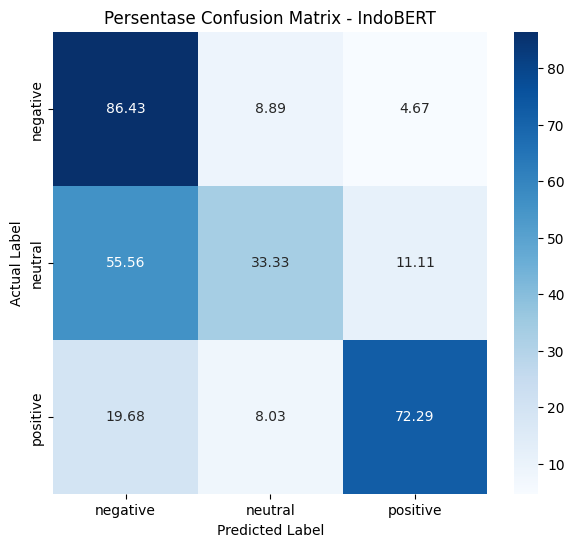


===== PERSENTASE CONFUSION MATRIX mBERT =====
          negative  neutral  positive
negative     99.64      0.0      0.36
neutral      97.22      0.0      2.78
positive     44.58      0.0     55.42


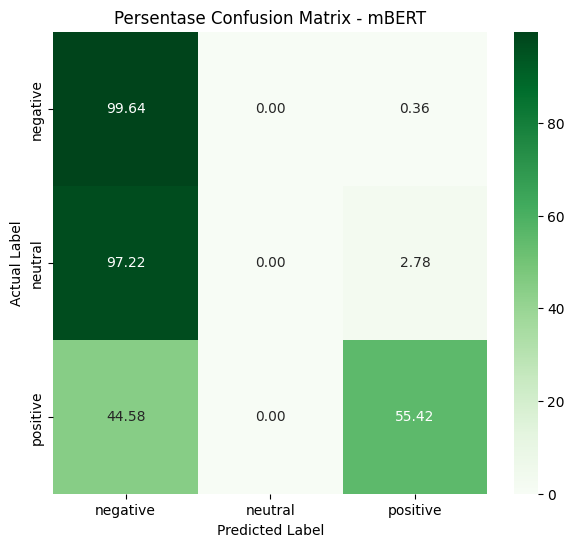

In [ ]:
# =====================================================
# VISUALISASI PERSENTASE CONFUSION MATRIX
# INDO-BERT DAN mBERT
# =====================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# LABEL
# =====================================================
labels = label_encoder.classes_

# =====================================================
# PERSENTASE CONFUSION MATRIX INDOBERT
# =====================================================
row_total_indobert = cm_indobert.sum(axis=1)

cm_indobert_percent = (
    cm_indobert / row_total_indobert[:, np.newaxis]
) * 100

df_cm_indobert_percent = pd.DataFrame(
    cm_indobert_percent,
    index=labels,
    columns=labels
)

print("\n===== PERSENTASE CONFUSION MATRIX INDOBERT =====")
print(df_cm_indobert_percent.round(2))

# =====================================================
# VISUALISASI INDOBERT
# =====================================================
plt.figure(figsize=(7,6))

sns.heatmap(
    df_cm_indobert_percent,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title("Persentase Confusion Matrix - IndoBERT")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# =====================================================
# PERSENTASE CONFUSION MATRIX mBERT
# =====================================================
row_total_mbert = cm_mbert.sum(axis=1)

cm_mbert_percent = (
    cm_mbert / row_total_mbert[:, np.newaxis]
) * 100

df_cm_mbert_percent = pd.DataFrame(
    cm_mbert_percent,
    index=labels,
    columns=labels
)

print("\n===== PERSENTASE CONFUSION MATRIX mBERT =====")
print(df_cm_mbert_percent.round(2))

# =====================================================
# VISUALISASI mBERT
# =====================================================
plt.figure(figsize=(7,6))

sns.heatmap(
    df_cm_mbert_percent,
    annot=True,
    fmt='.2f',
    cmap='Greens'
)

plt.title("Persentase Confusion Matrix - mBERT")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()